# Homogeneity in political party speeches
## ENSAE 3A 2025-2026 Machine Learning for Natural Language Processing
## Étienne Marécaux

In [1]:
#Importations
import pandas as pd
import contextlib
import polars as pl
from tqdm import tqdm
import os
import random
import numpy as np
import gensim
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import spacy
import plotly.express as px
import seaborn as sns
import plotly.io as pio
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 123456789
os.environ["PYTHONHASHSEED"] = str(SEED)      # deterministic dict order
random.seed(SEED)                            # Python's random
np.random.seed(SEED)                         # NumPy random

# Lecture des métadonnées

In [3]:
csv = pd.read_csv("data/archelect_search.csv")

/tmp/ipykernel_1611973/4181532743.py:1: DtypeWarning: Columns (8,9,10,12,28,29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  csv = pd.read_csv("data/archelect_search.csv")


In [4]:
csv.shape

(33030, 42)

In [5]:
csv.columns

Index(['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour',
       'cote', 'departement', 'departement-nom', 'departement-insee',
       'identifiant de circonscription', 'images', 'pdf', 'ocr_url',
       'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age',
       'titulaire-age-calcule', 'titulaire-age-tranche',
       'titulaire-profession', 'titulaire-mandat-en-cours',
       'titulaire-mandat-passe', 'titulaire-associations',
       'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste',
       'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom',
       'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule',
       'suppleant-age-tranche', 'suppleant-profession',
       'suppleant-mandat-en-cours', 'suppleant-mandat-passe',
       'suppleant-associations', 'suppleant-autres-statuts',
       'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations'],
      dtype='object')

In [6]:
csv.head()

,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,France;Élections législatives;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,non
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,France;Ve République;Élections législatives;As...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,conseiller municipal,non mentionné,non mentionné,prisonnier de guerre,Union pour la nouvelle République,non mentionné,non
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non
3,EL009_L_1958_11_001_01_1_PF_04,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,35,entre 30 et 39 ans,greffier de paix,conseiller municipal;conseiller général,non mentionné,non mentionné,combattant,non mentionné,non mentionné,oui
4,EL009_L_1958_11_001_01_1_PF_05,1958-11-23,Ve République;Assemblée Nationale;Élections lé...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur;président Coopérative élevage,non mentionné,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans,non mentionné,non


In [7]:
csv['date'] = pd.to_datetime(csv['date'])
csv['date'].head()

0   1958-11-23
1   1958-11-23
2   1958-11-23
3   1958-11-23
4   1958-11-23
Name: date, dtype: datetime64[ns]

In [8]:
# On ne garde que l'élection de 1988
csv['contexte-tour'].loc[csv['date'].dt.year==1988]

23341    1
23342    1
23343    1
23344    1
23345    1
        ..
26887    2
26888    2
26889    2
26890    2
26891    2
Name: contexte-tour, Length: 3551, dtype: int64

In [9]:
csv['contexte-election'].value_counts()

contexte-election
législatives               32625
européennes                  235
présidentielle               106
régionales                    25
législatives|régionales       17
législatives partielles       14
cantonales                     8
Name: count, dtype: int64

# Lecture des transcriptions

In [10]:
csv1988 = csv.loc[(csv['date'].dt.year==1988) & (csv['contexte-election']=='législatives')]

In [11]:
print(csv1988['contexte-election'].value_counts())
print(csv1988["contexte-tour"].value_counts())

contexte-election
législatives    3540
Name: count, dtype: int64
contexte-tour
1    2686
2     854
Name: count, dtype: int64


In [12]:
csv1988.shape

(3540, 42)

In [13]:
csv1988 = pl.from_pandas(csv1988)
csv1988 = csv1988.filter(
    pl.col("titulaire-nom").str.strip_chars().str.to_lowercase() != "non mentionné"
)
'''csv1988.get_column("titulaire-nom").value_counts().sort("count") # 79 values "non mentionné"
csv1988.with_columns(
    pl.col("titulaire-nom").str.len_chars().alias("titulaire-nom-length")
).sort("titulaire-nom-length").select(pl.selectors.by_name("titulaire-nom","titulaire-nom-length"))
csv1988 = csv1988.filter(pl.col("titulaire-nom") != "non mentionné") # 3461 rows
csv1988.shape'''

'csv1988.get_column("titulaire-nom").value_counts().sort("count") # 79 values "non mentionné"\ncsv1988.with_columns(\n    pl.col("titulaire-nom").str.len_chars().alias("titulaire-nom-length")\n).sort("titulaire-nom-length").select(pl.selectors.by_name("titulaire-nom","titulaire-nom-length"))\ncsv1988 = csv1988.filter(pl.col("titulaire-nom") != "non mentionné") # 3461 rows\ncsv1988.shape'

In [14]:
def read_transcript(id):
    try:
        with open("data/text_files/1988/legislatives/"+id+".txt", "r") as file:
            return file.read()
    except FileNotFoundError:
        return 'error'

csv1988 = csv1988.with_columns(
    pl.col("id").map_elements(read_transcript, return_dtype=pl.String).alias("transcript")
)
csv1988.filter(pl.col("transcript") == '') # only 1 missing transcript
csv1988 = csv1988.filter((pl.col("transcript") != '') & (pl.col("transcript") != 'error')).to_pandas() # 1504 rows

# Affiliation politique / titulaire-soutien

In [15]:
# La variable titulaire-soutien contient une liste de partis politiques pour chaque profession de foi
# cependant il faut traiter cette liste car il peut y avoir plusieurs soutiens
print(csv1988['titulaire-soutien'].value_counts().head(20))

titulaire-soutien
non mentionné                                                                                                      636
Parti communiste français                                                                                          238
Front national                                                                                                     236
Rassemblement pour la République;Union pour la démocratie française                                                122
Parti socialiste                                                                                                    77
Union pour la démocratie française;Rassemblement pour la République                                                 17
Rassemblement pour la République;Union pour la démocratie française;Centre national des indépendants et paysans     16
Rassemblement pour la République                                                                                    12
Union pour la démocratie franç

In [16]:
# Explode => un seul titulaire soutien par ligne, mais plusieurs lignes par profession
csv1988_exploded = csv1988.copy()
csv1988_exploded["titulaire-soutien"] = csv1988_exploded["titulaire-soutien"].str.split(";")
csv1988_exploded = csv1988_exploded.explode("titulaire-soutien")

In [17]:
csv1988_exploded["titulaire-soutien"].value_counts().head(20)

titulaire-soutien
non mentionné                                                636
Parti communiste français                                    240
Front national                                               238
Union pour la démocratie française                           203
Rassemblement pour la République                             198
Parti socialiste                                              86
Centre national des indépendants et paysans                   43
Centre des démocrates sociaux                                 14
Mouvement des radicaux de gauche                              12
Comités Juquin                                                 9
Verts alternatifs                                              6
Parti radical                                                  6
Verts                                                          5
socialiste                                                     5
centriste                                                      5
Parti r

In [18]:
# Simplification en 8 partis principaux selon https://fr.wikipedia.org/wiki/Liste_des_partis_politiques_en_France_sous_la_Cinqui%C3%A8me_R%C3%A9publique
corrections = {
    'non mentionné' : '',
    'indépendant' : '',
    'indépendants' : '',
    'sans étiquette' : '',
    'libre' : '',
    'libres' : '',
    'non inscrits' : '',
    'non inscrit' : '',
    'sans parti politique' : '',
    'hors des partis' : '',
    'abertzale' : '',
    'Fédération nationale des indépendants' : '',
    'Front national' : 'Extrême droite',
    'Rassemblement pour la République' : 'Droite',
    'Union gaulliste pour la démocratie' : 'Droite',
    'Mouvement des gaullistes populaires' : 'Droite',
    'Mouvement solidarité participation' : 'Droite',
    'Parti républicain' : 'Droite',
    'divers droite' : 'Droite',
    'droite' : 'Droite',
    'Centre national des indépendants et paysans' : 'Droite',
    'centre droit' : 'Centre droit', # proche udf en 1988
    'Parti ouvrier européen' : 'Centre droit', # proche udf en 1988
    'Centre des démocrates sociaux' : 'Centre droit',
    'Républicains de progrès' : 'Centre droit',
    'Parti radical' : 'Centre droit',
    'radical' : 'Centre droit',
    'Union pour la démocratie française' : 'Centre droit',
    'Parti radical-socialiste' : 'Centre droit', # pas parti radical de gauche
    'centriste' : 'Centre',
    'centre' : 'Centre',
    'Démocrates de progrès' : 'Centre',
    'centre gauche' : 'Centre gauche',
    'Parti social-démocrate' : 'Centre gauche',
    'Parti démocrate français' : 'Centre gauche',
    'Mouvement des radicaux de gauche' : 'Centre gauche',
    'gauche' : 'Gauche',
    'socialiste' : 'Gauche',
    'socialistes' : 'Gauche',
    'Humaniste' : 'Gauche',
    'Parti humaniste' : 'Gauche',
    'Parti socialiste' : 'Gauche',
    'Parti socialiste unifié' : 'Gauche',
    'Mouvement rouge et vert' : 'Gauche',
    'Comités d\'initiative pour une nouvelle politique à gauche' : 'Gauche',
    'Parti communiste français' : 'Gauche',
    'Parti communiste réunionnais' : 'Gauche',
    'Parti communiste guadeloupéen' : 'Gauche',
    'Verts alternatifs' : 'Verts',
    'Parti vert' : 'Verts',
    'Jura écologie' : 'Verts',
    'vert indépendant' : 'Verts',
    'Mouvement écologique' : 'Verts',
    'Anjou écologie autogestion' : 'Verts',
    'Comités Juquin' : 'Extrême gauche' # LCR
}
csv1988_exploded['titulaire-soutien'] = csv1988_exploded['titulaire-soutien'].map(corrections)
print(csv1988_exploded['titulaire-soutien'].value_counts().head(40))

titulaire-soutien
                  653
Gauche            343
Droite            248
Extrême droite    238
Centre droit      228
Centre gauche      16
Verts              13
Extrême gauche      9
Centre              6
Name: count, dtype: int64


In [19]:
# On introduit un index de position
index_position = {
    'Extrême droite' : 1,    'Droite' : 0.8,
    'Centre droit' : 0.6,    'Centre gauche' : 0.4,
    'Gauche' : 0.2, 'Extrême gauche':0, 'Centre':0.5, 'Verts':0.4, '':None
}
csv1988_exploded['titulaire-soutien-position'] = csv1988_exploded['titulaire-soutien'].replace(index_position)

In [20]:
csv1988_exploded['titulaire-soutien-position'].value_counts().head(30)

titulaire-soutien-position
0.2    343
0.8    248
1.0    238
0.6    228
0.4     29
0.0      9
0.5      6
Name: count, dtype: int64

In [21]:
temp_aggregation = pd.to_numeric(csv1988_exploded["titulaire-soutien-position"], errors='coerce').groupby(level=0).mean()

In [22]:
temp_aggregation.value_counts().head(30)

titulaire-soutien-position
0.200000    330
1.000000    236
0.700000    143
0.733333     34
0.600000     23
0.800000     20
0.400000     16
0.300000      9
0.000000      8
0.500000      5
0.666667      4
0.633333      2
0.550000      1
0.900000      1
0.133333      1
0.700000      1
0.800000      1
Name: count, dtype: int64

In [23]:
df = pd.merge(csv1988, temp_aggregation, how='left', left_index=True, right_index=True)

# Embeddings des transcripts avec Doc2Vec

In [24]:
# inspired from https://www.geeksforgeeks.org/nlp/doc2vec-in-nlp/

In [25]:
nlp = spacy.load('fr_core_news_sm')

In [26]:
df = df.dropna(subset=['transcript']).copy()
df = df.reset_index(drop=True)
def tag_transcript(i:int,s:str):
    w = [str(token) for token in nlp.make_doc(s)]
    return TaggedDocument(words=w,tags=[str(i)]) 

# preprocess des documents, et création des TaggedDocuments
tagged_data = [tag_transcript(i,doc) for i,doc in tqdm(enumerate(df["transcript"]), desc="Tagging transcripts")]
tagged_data[0:2]

Tagging transcripts: 0it [00:00, ?it/s]

Tagging transcripts: 8it [00:00, 72.28it/s]

Tagging transcripts: 18it [00:00, 83.88it/s]

Tagging transcripts: 27it [00:00, 84.59it/s]

Tagging transcripts: 36it [00:00, 85.41it/s]

...

Tagging transcripts: 1462it [00:14, 140.72it/s]

Tagging transcripts: 1481it [00:14, 153.91it/s]

Tagging transcripts: 1497it [00:14, 147.52it/s]

Tagging transcripts: 1504it [00:14, 101.32it/s]

[TaggedDocument(words=['Élections', 'Législatives', 'du', '5', 'Juin', '1988', '-', 'Département', 'de', "l'", 'Ain', '-', '1re', 'circonscription', '\n', 'Sciences', 'Po', '/', 'fonds', 'CEVIPOF', '\n', 'Maintenant', 'la', 'force', "d'", 'avenir', "c'", 'est', 'le', 'Front', 'National', '\n', 'Appel', 'aux', 'Français', ',', '\n', 'Le', '24', 'Avril', ',', '4.400.000', 'électrices', 'et', 'électeurs', "m'", 'ont', 'fait', 'confiance', ':', '-', 'pour', 'promouvoir', 'le', 'programme', 'de', 'redressement', 'national', ',', '-', 'pour', 'réduire', 'le', 'chômage', ',', "l'", 'immigration', ',', "l'", 'insécurité', ',', '-', 'pour', 'lutter', 'contre', 'le', 'socialisme', 'bureaucratique', 'et', 'fiscaliste', '.', 'Je', 'leur', 'demande', 'de', 'confirmer', 'et', "d'", 'amplifier', 'leur', 'vote', 'le', '5', 'juin', 'prochain', '.', '\n', 'La', 'réélection', 'de', 'François', 'MITTERRAND', 'a', 'été', 'rendue', 'possible', 'par', 'les', 'erreurs', 'et', 'les', 'faiblesses', 'du', 'RPR',

In [27]:
# Entraînement Doc2Vec
model = Doc2Vec(vector_size=60,
                min_count=5, epochs=50,
               seed=SEED)
model.build_vocab(tagged_data)
model.train(tagged_data,
            total_examples=model.corpus_count,
            epochs=model.epochs)

In [28]:
# On ajoute les embeddings au dataframe df
df['vector'] = [model.dv[str(i)] for i in range(len(df))]

# Visualisation en faible dimension

In [29]:
pio.renderers.default = 'iframe'

In [30]:
df1 = pl.from_pandas(df)
matrix = np.array(df1["vector"].to_list())
matrix.shape

(1504, 60)

In [31]:
df1 = df1.with_columns(
    pl.col("titulaire-soutien")
    .str.split(";")
    .list.eval(
        pl.element().replace_strict(corrections, default=pl.element())
    )
    .list.unique()
    .alias("titulaire-soutien-list")
)

In [32]:
df1 = df1.with_columns(
    pl.col("titulaire-soutien-list")
    .list.get(0)
    .fill_null("")
    .alias("position-politique")
)

In [33]:
tsne = TSNE(
    n_components=2, 
    perplexity=50,
    max_iter=500,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
coords = tsne.fit_transform(matrix)

df1 = df1.with_columns([
    pl.Series(name="x", values=coords[:, 0]),
    pl.Series(name="y", values=coords[:, 1])
])

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 1504 samples in 0.001s...
[t-SNE] Computed neighbors for 1504 samples in 0.101s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1504
[t-SNE] Computed conditional probabilities for sample 1504 / 1504
[t-SNE] Mean sigma: 2.063506


[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.441498


[t-SNE] KL divergence after 500 iterations: 1.843105


In [34]:
df_filtered = df1.filter(pl.col("titulaire-soutien-position").is_not_null())

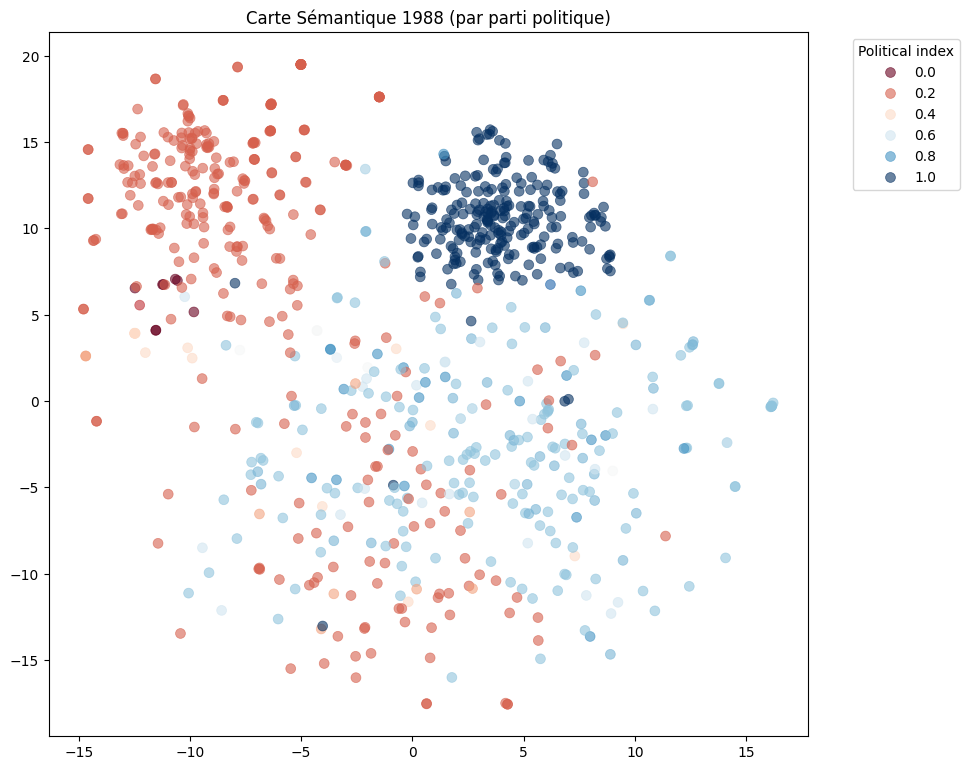

In [35]:
df_pandas = df1.to_pandas()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_pandas,
    x="x",
    y="y",
    hue="titulaire-soutien-position",
    palette="RdBu",  # Rouge (gauche) à Bleu (droite)
    alpha=0.6,
    s=50,
    edgecolor=None
)
plt.title("Carte Sémantique 1988 (par parti politique)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Political index")
plt.tight_layout()
_ = plt.xlabel(None)
_ = plt.ylabel(None)
plt.savefig("carte_semantique.png")
plt.show()

# Stratégies de citation NER

In [36]:
TITRES_A_EXCLURE = {
    "monsieur", "madame", "mademoiselle"
}

def extract_person_names(text):
    if not isinstance(text, str) or text == 'error':
        return []
    
    doc = nlp(text)
    names = []

    for ent in doc.ents:
        if ent.label_ == "PER":
            if ent.text.lower().strip() in TITRES_A_EXCLURE:
                continue
            names.append(ent.text.lower().strip())

    return names

df['person_mentions'] = df['transcript'].apply(extract_person_names)

df_mentions = df.explode('person_mentions')

df_mentions['person_mentions_clean'] = (
    df_mentions['person_mentions']
    .str.title()
)

In [37]:
top10 = (
    df_mentions['person_mentions_clean']
    .value_counts()
    .head(10)
)

print(top10)

person_mentions_clean
François Mitterrand           1183
Président De La République     578
Michel Rocard                  352
Jean-Marie Le Pen              194
Le Pen                         172
Premier Ministre               130
Président                      110
R.P.R.                         100
André Lajoinie                  90
Chirac                          85
Name: count, dtype: int64


In [38]:
top10_names = top10.index.tolist()

df_top10 = df_mentions[df_mentions['person_mentions_clean'].isin(top10_names)]

analysis_top10 = (
    df_top10
    .groupby(['titulaire-soutien-position', 'person_mentions'])
    .size()
    .unstack(fill_value=0)
)

print(analysis_top10)

person_mentions             andré lajoinie  chirac  françois mitterrand  \
titulaire-soutien-position                                                
0.000000                                 0       0                    1   
0.200000                                87      62                  424   
0.300000                                 0       3                   11   
0.400000                                 0       0                    3   
0.500000                                 0       0                    4   
0.600000                                 0       0                    1   
0.633333                                 0       0                    0   
0.666667                                 0       0                    0   
0.700000                                 0       3                   19   
0.733333                                 0       0                    4   
0.800000                                 0       0                    0   
0.800000                 

# Prédiction du parti politique

In [39]:
with open('stop_word_fr.txt', 'r', encoding='utf-8') as f:
    STOPWORDS = [line.strip().lower() for line in f if line.strip()]

stop_words_ML = {"error","rpr","gauche","droite","udf","front","union","centre"}
STOPWORDS_EXTENDED = list(set(STOPWORDS).union(stop_words_ML))

MAE: 0.0404
MSE: 0.0053
R² Score: 0.9555


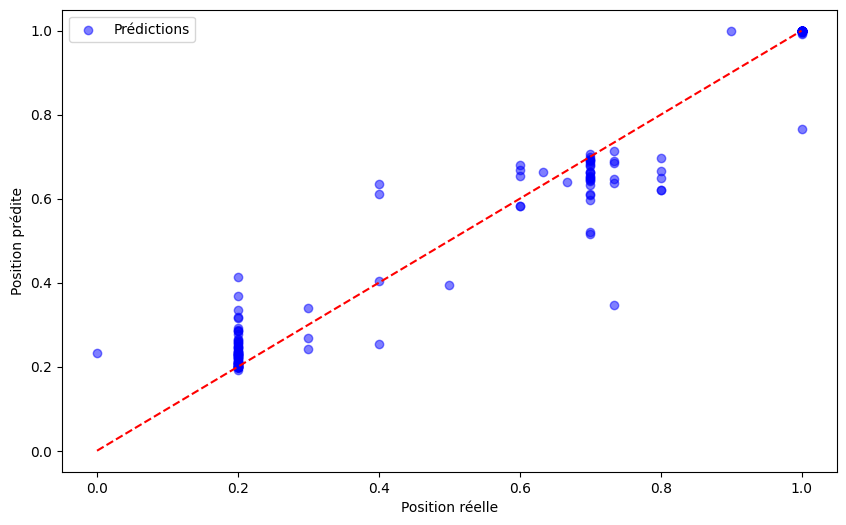

In [40]:
df_ml = df.dropna(subset=['titulaire-soutien-position', 'transcript'])

X = df_ml['transcript']
y = df_ml['titulaire-soutien-position']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

stop_words_rf = []

tfidf = TfidfVectorizer(max_features=5000, stop_words=STOPWORDS_EXTENDED)
X_train = tfidf.fit_transform(X_train_raw)
X_test = tfidf.transform(X_test_raw)

model = RandomForestRegressor(n_estimators=100, random_state=SEED)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color = 'blue', label = "Prédictions")
plt.plot([0, 1], [0, 1], '--', color='red')
plt.xlabel("Position réelle")
plt.ylabel("Position prédite")
plt.legend()
plt.savefig("random-forests.png")
plt.show()

             feature  importance
1018       collègues    0.150612
3065        national    0.130579
3220            paix    0.098962
2342     immigration    0.086313
1524          drogue    0.066132
3300           peine    0.049315
1420      différence    0.042840
2996            mort    0.037136
1060      communiste    0.036009
1915         extrême    0.031250
4663            unie    0.027023
2944      mitterrand    0.024616
2066        fortunes    0.013160
72                24    0.012487
2046          forces    0.009001
3685  présidentielle    0.007218
4003          rocard    0.006701
4086      référendum    0.006469
4315      socialisme    0.006447
3783   rassemblement    0.006196


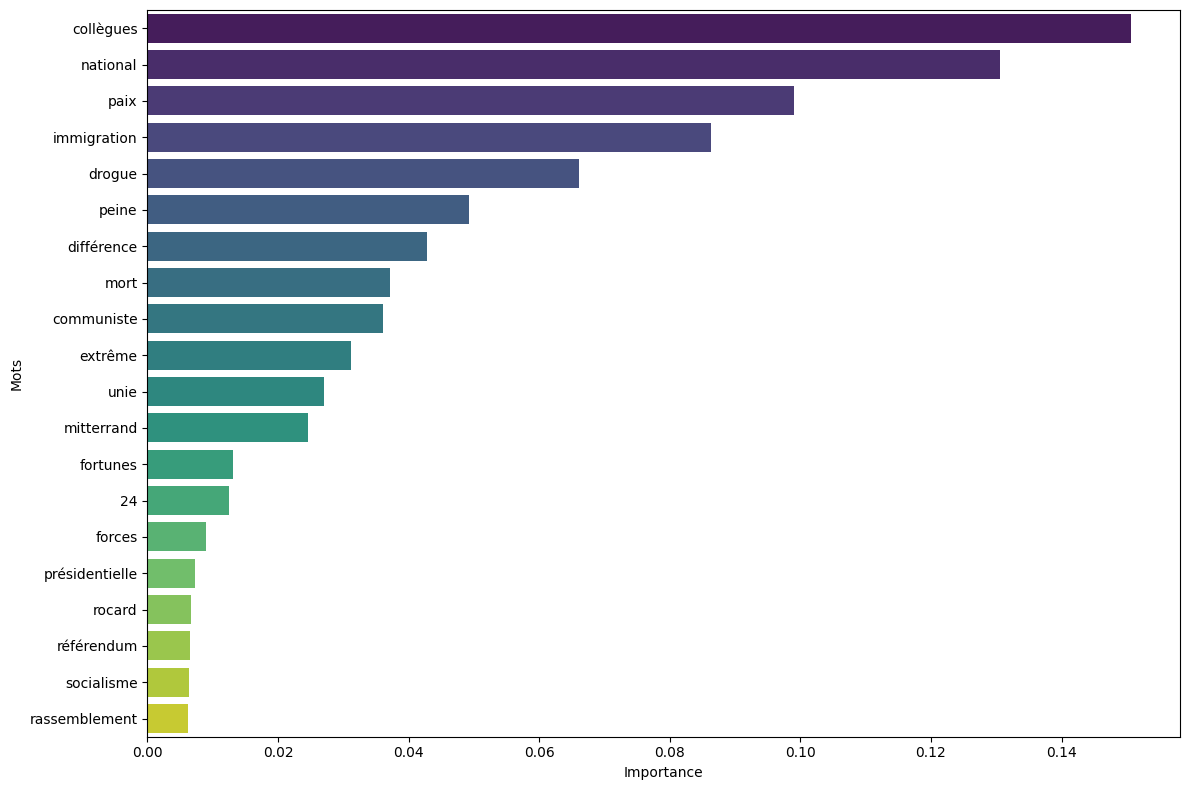

In [41]:
feature_importances = model.feature_importances_
feature_names = tfidf.get_feature_names_out()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(
    x='importance',
    y='feature',
    data=importance_df.head(20),  # Top 20
    palette='viridis'
)
plt.title("")
plt.xlabel("Importance")
plt.ylabel("Mots")
plt.tight_layout()
plt.savefig("mots-influents-rf.png")
plt.show()

MAE: 0.0822
MSE: 0.0105
R² score: 0.9115


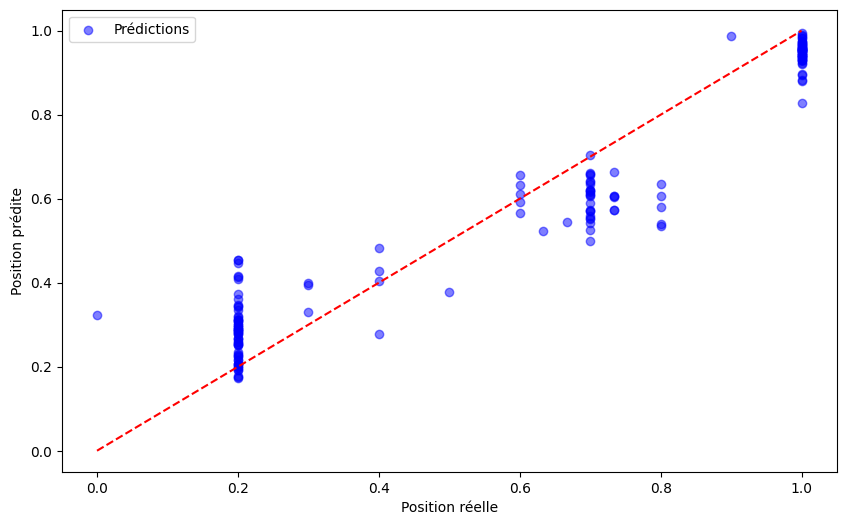

In [42]:
df_ml = df.dropna(subset=['titulaire-soutien-position', 'transcript'])

X = df_ml['transcript']
y = df_ml['titulaire-soutien-position']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

ml_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000, 
        ngram_range=(1, 2),
        sublinear_tf=True,
        stop_words = STOPWORDS_EXTENDED
    )),
    ('svr', SVR(kernel='linear', C=1.0))
])

ml_pipeline.fit(X_train_raw, y_train)

y_pred = ml_pipeline.predict(X_test_raw)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² score: {r2:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Prédictions')
plt.plot([0, 1], [0, 1], '--', color='red')
plt.xlabel("Position réelle")
plt.ylabel("Position prédite")
plt.legend()
plt.savefig("svr.png")
plt.show()

In [43]:
vectorizer = ml_pipeline.named_steps['tfidf']
svr_model = ml_pipeline.named_steps['svr']

feature_names = vectorizer.get_feature_names_out()

coeffs = svr_model.coef_.toarray().flatten()
top_pos_idx = coeffs.argsort()[-20:][::-1]   # 20 mots qui poussent vers un score plus haut
top_neg_idx = coeffs.argsort()[:20]          # 20 mots qui poussent vers un score plus bas

print("\n=== Mots les PLUS INFLUENTS (score + élevé) ===")
for i in top_pos_idx:
    print(f"{feature_names[i]:<30} coef = {coeffs[i]:.4f}")

print("\n=== Mots les PLUS INFLUENTS (score + bas) ===")
for i in top_neg_idx:
    print(f"{feature_names[i]:<30} coef = {coeffs[i]:.4f}")


=== Mots les PLUS INFLUENTS (score + élevé) ===
cni                            coef = 0.1574
pouvoirs                       coef = 0.1558
famille                        coef = 0.1279
berre                          coef = 0.1271
docteur                        coef = 0.1197
économique                     coef = 0.1188
national                       coef = 0.1184
entreprise                     coef = 0.1159
urc                            coef = 0.1043
nationale                      coef = 0.1040
olivier                        coef = 0.1024
cevipof elections              coef = 0.1004
général                        coef = 0.1003
immigration                    coef = 0.0996
région                         coef = 0.0954
vis                            coef = 0.0941
nation                         coef = 0.0932
présidence                     coef = 0.0920
conseiller général             coef = 0.0917
demain                         coef = 0.0906

=== Mots les PLUS INFLUENTS (score + bas) ===
fran

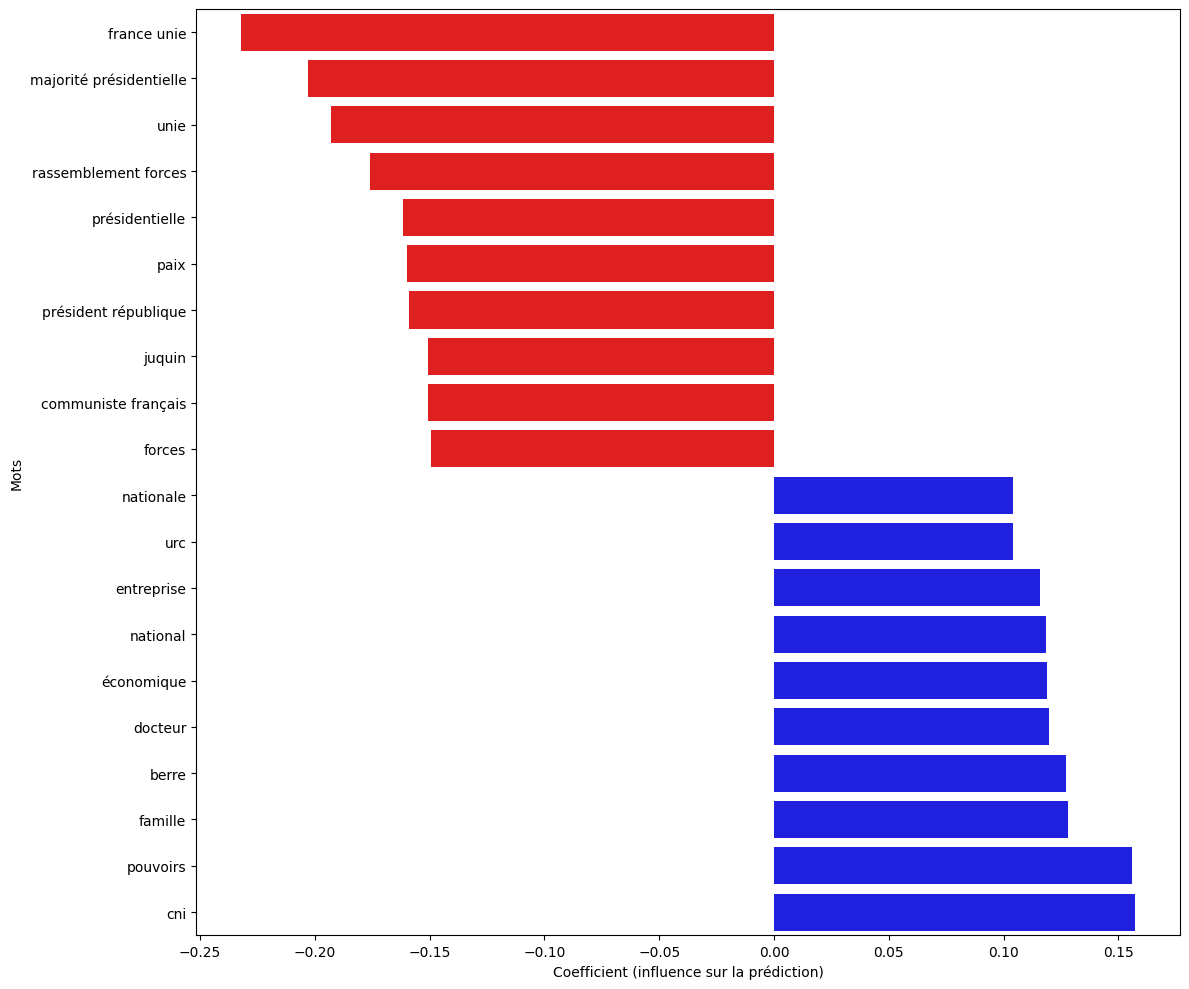

In [44]:
df_coef = pd.DataFrame({
    'feature': feature_names,
    'coef': coeffs
})

# 10 plus positifs (poussent vers score haut)
top_pos = df_coef.sort_values('coef', ascending=False).head(10)

# 10 plus négatifs (poussent vers score bas)
top_neg = df_coef.sort_values('coef', ascending=True).head(10)

df_plot = pd.concat([top_neg, top_pos])
df_plot['feature'] = df_plot['feature'].astype(str)

df_plot = df_plot.sort_values('coef')

plt.figure(figsize=(12, 10))
sns.barplot(
    x='coef',
    y='feature',
    data=df_plot,
    palette=['red' if c < 0 else 'blue' for c in df_plot['coef']]
)

plt.title("")
plt.xlabel("Coefficient (influence sur la prédiction)")
plt.ylabel("Mots")
plt.tight_layout()
plt.savefig("svr_top_positive_negative.png")
plt.show()

# Non concluant : BERT / BERT guidé

In [45]:
nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])

def lemmatize_politique(text):
    doc = nlp(text.lower())
    # On exclue les noms propres (PROPN) et les chiffres (NUM)
    # On garde les noms, adjectifs et verbes porteurs de sens
    tokens = [token.lemma_ for token in doc 
              if token.pos_ in ["NOUN", "ADJ", "VERB"] 
              and not token.is_stop 
              and len(token.text) > 3]
    return " ".join(tokens)

df1 = df1.with_columns(
    pl.col("transcript").map_elements(lemmatize_politique, return_dtype=pl.String).alias("clean_text")
)

KeyboardInterrupt: 

This error occurred in the following expression:
	col("transcript").python_udf()


In [ ]:
docs = df1["clean_text"].to_list()
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

zeroshot_topic_list = [
    "Écologie et Environnement", 
    "Sécurité et Justice", 
    "Pouvoir d'achat et Social", 
    "Économie et Fiscalité", 
    "Santé et Handicap", 
    "Éducation et Jeunesse", 
    "Immigration et Identité", 
    "Agriculture et Ruralité", 
    "Services publics et Territoires", 
    "Europe et International"
]

vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS_EXTENDED, 
    max_features=10000,
    ngram_range=(1, 2), 
    min_df=3,
    max_df = 0.5
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    zeroshot_topic_list=zeroshot_topic_list,
    zeroshot_min_similarity=0.5,
    verbose=True
)

embeddings = embedding_model.encode(docs, show_progress_bar=True)
topics, _ = topic_model.fit_transform(docs, embeddings)

df1 = df1.with_columns([
    pl.Series("theme_id", topics),
    pl.Series("theme_label", [topic_model.get_topic_info(t)["Name"].iloc[0] for t in topics])
])

print(topic_model.get_topic_info())

In [ ]:
docs = df1["clean_text"].to_list()
print(len(docs))

embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = embedding_model.encode(docs, show_progress_bar=True)

In [ ]:
zeroshot_topic_list = [
    "économie", 
    "sécurité", 
    "environnement",
    "pouvoir d'achat"
]

In [ ]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    zeroshot_topic_list=zeroshot_topic_list,
    zeroshot_min_similarity=0.7,  # Seuil de similitude
    vectorizer_model=CountVectorizer(
        stop_words=STOPWORDS_EXTENDED,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.5,
    ),
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

In [ ]:
umap_model = UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=15, min_samples=5, prediction_data=True)
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS_EXTENDED + ["monsieur", "madame", "dimanche", "uni", "élection"],
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.7
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    zeroshot_topic_list=zeroshot_topic_list,
    zeroshot_min_similarity=0.7,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

In [ ]:
df1 = df1.with_columns([
    pl.Series("theme_id", topics),
    pl.Series("theme_label", [topic_model.get_topic_info(t)["Name"].iloc[0] for t in topics])
])

print(topic_model.get_topic_info())